In [23]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import mediapipe as mp
from tqdm import tqdm

# MST-E CONFIG
MST_E_ROOT = r'C:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\DatasetAnnotation\MonkSkinToneDataset\mst-e_data'
MST_E_CSV_RAW = os.path.join(MST_E_ROOT, 'mst-e_image_details.csv')
MST_E_OUTPUT_DIR = r'G:\Thesis\MonkSkinTone_Dataset\Segmented_MSTE'

# FACET CONFIG
FACET_ROOT_IMAGES = r'G:\Thesis\FACET_Dataset\Images' 
FACET_CSV_RAW = r'G:\Thesis\FACET_Dataset\Annotations\annotations\annotations.csv'
FACET_OUTPUT_DIR = r'G:\Thesis\FACET_Dataset\Segmented_FACET_0.2'

# Create Output Dirs
os.makedirs(MST_E_OUTPUT_DIR, exist_ok=True)
os.makedirs(FACET_OUTPUT_DIR, exist_ok=True)

# SEGMENTATION ENGINE
def segment_face(image, face_mesh):
    """
    Accepts loaded image, returns cropped face with black background.
    """
    h_img, w_img, _ = image.shape
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(rgb_image)

    if not results.multi_face_landmarks:
        return None 

    landmarks = results.multi_face_landmarks[0]
    
    # Get Geometry
    points = np.array([(int(lm.x * w_img), int(lm.y * h_img)) for lm in landmarks.landmark])
    x, y, w_box, h_box = cv2.boundingRect(points)
    
    # Filter: Too Small or Weird Aspect Ratio
    if w_box < 50 or h_box < 50: return None
    aspect = h_box / w_box
    if aspect < 0.6 or aspect > 2.5: return None

    # Masking
    mask = np.zeros((h_img, w_img), dtype=np.uint8)
    hull = cv2.convexHull(points)
    cv2.fillConvexPoly(mask, hull, 255)
    segmented = cv2.bitwise_and(image, image, mask=mask)

    # Cropping with Padding
    pad = 10
    x = max(0, x - pad)
    y = max(0, y - pad)
    w_box = min(w_img, x + w_box + 2*pad) - x
    h_box = min(h_img, y + h_box + 2*pad) - y
    
    return segmented[y:y+h_box, x:x+w_box]

# PROCESS MST-E
def process_mste():
    print("\n--- Processing MST-E Dataset ---")
    df = pd.read_csv(MST_E_CSV_RAW)
    df = df.rename(columns={'MST': 'mst_label'})
    
    valid_paths = []
    
    with mp.solutions.face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5) as face_mesh:
        
        for i, row in tqdm(enumerate(df.itertuples(index=False)), total=len(df)):
            # Handle Nested Paths: subject_X/image.jpg
            sub_folder = str(row.subject_name)
            fname = str(row.image_ID)
            
            input_path = os.path.join(MST_E_ROOT, sub_folder, fname)
            out_name = f"{sub_folder}_{fname}"
            output_path = os.path.join(MST_E_OUTPUT_DIR, out_name)
            
            if os.path.exists(output_path):
                valid_paths.append(output_path); continue
            
            if not os.path.exists(input_path):
                valid_paths.append(None); continue
                
            try:
                img = cv2.imread(input_path)
                if img is None: valid_paths.append(None); continue
                
                crop = segment_face(img, face_mesh)
                if crop is not None:
                    cv2.imwrite(output_path, crop)
                    valid_paths.append(output_path)
                else:
                    valid_paths.append(None)
            except:
                valid_paths.append(None)
                
            if i % 200 == 0: gc.collect()

    df['segmented_path'] = valid_paths
    df_clean = df.dropna(subset=['segmented_path'])
    out_csv = os.path.join(MST_E_OUTPUT_DIR, 'mst_e_final.csv')
    df_clean.to_csv(out_csv, index=False)
    print(f"MST-E Done. Saved {len(df_clean)} images.")
    return out_csv

# PROCESS FACET
def process_facet(consensus_threshold=0.5):
    print("\n--- Processing FACET Dataset ---")
    # Load and filter FACET logic
    df = pd.read_csv(FACET_CSV_RAW)
    skin_cols = [c for c in df.columns if c.startswith("skin_tone_")]
    
    # Filter valid labels
    df = df[df[skin_cols].sum(axis=1) > 0] # Must have votes

    # Calculate Consensus Agreement
    # Find the max votes for the winning class
    max_votes = df[skin_cols].max(axis=1)
    # Find total votes cast
    total_votes = df[skin_cols].sum(axis=1)
    
    # Calculate Agreement Ratio (e.g., 8/10 = 0.8)
    agreement_ratio = max_votes / total_votes
    
    # --- FILTERING STEP ---
    # Only keep rows where agreement >= threshold
    initial_len = len(df)
    df = df[agreement_ratio >= consensus_threshold]
    print(f"Consensus Filter: Dropped {initial_len - len(df)} images with low annotator agreement (<{consensus_threshold*100}%).")
    
    # 4. Assign Final Label
    df["mst_label"] = df[skin_cols].idxmax(axis=1).str.replace("skin_tone_", "")
    
    # 5. Clean up 'na' and convert to int
    df = df[df['mst_label'] != "na"]
    df['mst_label'] = df['mst_label'].astype(int)

    valid_paths = []
    
    with mp.solutions.face_mesh.FaceMesh(static_image_mode=True, max_num_faces=1, refine_landmarks=True, min_detection_confidence=0.5) as face_mesh:
        
        # Iterating
        for i, row in tqdm(enumerate(df.itertuples(index=False)), total=len(df)):
            fname = row.filename # FACET usually has 'filename' or 'image_id'
            input_path = os.path.join(FACET_ROOT_IMAGES, fname)
            output_path = os.path.join(FACET_OUTPUT_DIR, fname)
            
            if os.path.exists(output_path):
                valid_paths.append(output_path); continue
            
            if not os.path.exists(input_path):
                valid_paths.append(None); continue

            try:
                img = cv2.imread(input_path)
                if img is None: valid_paths.append(None); continue
                
                crop = segment_face(img, face_mesh)
                if crop is not None:
                    cv2.imwrite(output_path, crop)
                    valid_paths.append(output_path)
                else:
                    valid_paths.append(None)
            except:
                valid_paths.append(None)
                
            if i % 500 == 0: gc.collect()

    df['segmented_path'] = valid_paths
    df_clean = df.dropna(subset=['segmented_path'])
    # Add dummy subject name for compatibility
    df_clean['subject_name'] = df_clean['filename'] 
    
    out_csv = os.path.join(FACET_OUTPUT_DIR, 'facet_final.csv')
    df_clean.to_csv(out_csv, index=False)
    print(f"FACET Done. Saved {len(df_clean)} images.")
    return out_csv

In [24]:
# mste_out_csv_path = process_mste()

In [25]:
# facet_out_csv_path = process_facet(consensus_threshold=0.2)

In [26]:
import os
import random
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg16
import torchvision.models as models

In [27]:
# 0. REPRODUCIBILITY & DEVICE
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [28]:
# 1. PREPROCESSOR (RGB -> LAB, RESIZE, OPTIONAL AUGMENTATION)
class PaperPreprocessor:
    """
    Preprocessing aligned with the paper:
    - Input: BGR image (cv2)
    - Convert to RGB
    - Optional H/V flips (augmentation)
    - Resize to 224x224
    - Convert to LAB (OpenCV)
    - Return LAB tensor [3, H, W] in OpenCV's LAB range (no /255)
    """
    def __init__(self, augment: bool = False):
        self.augment = augment
        self.target_size = (224, 224)

    def __call__(self, img_bgr: np.ndarray) -> torch.Tensor:
        # BGR -> RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Data augmentation (paper: horizontal + vertical flips)
        if self.augment:
            if np.random.rand() < 0.5:
                img_rgb = cv2.flip(img_rgb, 1)  # horizontal
            if np.random.rand() < 0.5:
                img_rgb = cv2.flip(img_rgb, 0)  # vertical

        # Resize
        img_rgb = cv2.resize(img_rgb, self.target_size, interpolation=cv2.INTER_AREA)

        # RGB -> LAB (OpenCV's 8-bit LAB)
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB)  # uint8, shape [H,W,3]

        # To float tensor [C,H,W]; keep OpenCV range (no division by 255)
        img_lab = torch.from_numpy(img_lab.astype(np.float32)).permute(2, 0, 1)
        # img_lab = torch.tensor(img_lab, dtype=torch.float32).permute(2,0,1) / 255.0

        return img_lab

In [ ]:
# 2. MODEL: VGG-16 REGRESSION (NO PRETRAINED WEIGHTS)
class PaperVGG16Regression(nn.Module):
    """
    VGG-16 based regression model as described in the paper:
    - VGG-16 backbone, no pretrained weights
    - Fully connected regressor head:
        25088 -> 4096 -> 1024 -> 1
    - ReLU activations + Dropout(0.5) in FC layers
    - Output: single raw float (regression MST estimate)
    """
    def __init__(self):
        super().__init__()

        # base = models.vgg16_bn(weights=models.VGG16_BN_Weights.DEFAULT)
        base = models.vgg16_bn(weights=None)

        self.features = base.features  # conv + BN + ReLU + pooling layers

        # Replace classifier with custom regression head
        self.reg_head = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(25088, 4096),
            nn.BatchNorm1d(4096),
            nn.Sigmoid(),
            nn.Dropout(0.5),

            nn.Linear(4096, 1024),
            nn.BatchNorm1d(1024),
            nn.Sigmoid(),
            nn.Dropout(0.5),

            nn.Linear(1024, 1)   # raw regression output
        )

    def forward(self, x):
        x = self.features(x)
        x = self.reg_head(x)
        return x

In [30]:
# 3. DATASET
class SkinToneDataset(Dataset):
    """
    Expects a CSV with columns:
        - segmented_path: path to face-segmented image
        - mst_label: Monk Skin Tone label (1..10, continuous allowed)
    """
    def __init__(self, df: pd.DataFrame, transform: PaperPreprocessor):
        self.paths = df["segmented_path"].tolist()
        self.labels = df["mst_label"].astype(float).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Failed to read image: {img_path}")

        img = self.transform(img)
        label = torch.tensor(label, dtype=torch.float32)

        return img, label

In [31]:
# 4. TRAIN / VAL SPLIT + DATALOADERS
def build_dataloaders(csv_path: str, batch_size: int = 32, val_ratio: float = 0.2):
    """
    Builds train/validation DataLoaders with an 80/20 split.
    If you want identity-based splitting, you can extend this
    to group by 'subject_name' and split on that.
    """
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["segmented_path", "mst_label"])

    indices = np.arange(len(df))
    np.random.shuffle(indices)

    split = int(len(indices) * (1 - val_ratio))
    train_idx = indices[:split]
    val_idx = indices[split:]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    print(f"Total samples: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")

    train_transform = PaperPreprocessor(augment=True)
    val_transform = PaperPreprocessor(augment=False)

    train_ds = SkinToneDataset(train_df, transform=train_transform)
    val_ds = SkinToneDataset(val_df, transform=val_transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    return train_loader, val_loader

In [32]:
# 5. METRICS
def accuracy_at_threshold(preds: torch.Tensor, labels: torch.Tensor, dist: float = 0.5) -> float:
    """
    Accuracy as defined in the paper:
    fraction of samples such that |pred - label| <= dist
    """
    diffs = torch.abs(preds - labels)
    return (diffs <= dist).float().mean().item()

In [33]:
# 6. TRAINING LOOP
def train_paper_model(
    csv_path: str,
    num_epochs: int = 40,
    batch_size: int = 32,
    lr: float = 1e-5,
    momentum: float = 0.9,
    patience: int = 8,                  # early stopping patience
    checkpoint_path: str = "best_model.pth",
    use_amp: bool = False               # optional mixed precision
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ============================================================
    # BUILD LOADERS
    # ============================================================
    train_loader, val_loader = build_dataloaders(csv_path, batch_size=batch_size)

    # ============================================================
    # MODEL, LOSS, OPTIMISER
    # ============================================================
    model = PaperVGG16Regression().to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    scaler = torch.amp.GradScaler(device, enabled=use_amp)

    best_val_loss = float("inf")
    epochs_without_improve = 0

    print(f"Training on {device} with early stopping (patience={patience})")

    # ============================================================
    # EPOCH LOOP
    # ============================================================
    for epoch in range(num_epochs):

        # ----------------------------------------------------------
        # TRAINING
        # ----------------------------------------------------------
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", ncols=120)

        for imgs, labels in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            # with torch.amp.autocast(device, enabled=use_amp):
            with torch.amp.autocast('cuda', enabled=use_amp):
                preds = model(imgs).squeeze(1)
                loss = criterion(preds, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # ----------------------------------------------------------
        # VALIDATION (RUN EVERY EPOCH)
        # ----------------------------------------------------------
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                preds = model(imgs).squeeze(1)
                loss = criterion(preds, labels)

                val_loss += loss.item()
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        avg_val_loss = val_loss / len(val_loader)

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        acc05 = accuracy_at_threshold(all_preds, all_labels, dist=0.5)
        acc10 = accuracy_at_threshold(all_preds, all_labels, dist=1.0)
        acc20 = accuracy_at_threshold(all_preds, all_labels, dist=2.0)

        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] | "
            f"TrainLoss={avg_train_loss:.4f} | ValLoss={avg_val_loss:.4f}\n"
            f"Acc@0.5={acc05*100:.2f}% | Acc@1.0={acc10*100:.2f}% | Acc@2.0={acc20*100:.2f}%\n"
        )

        # ----------------------------------------------------------
        # EARLY STOPPING + BEST CHECKPOINT
        # ----------------------------------------------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improve = 0

            torch.save(model.state_dict(), checkpoint_path)
            print(f"✓ Saved new best model to {checkpoint_path} (ValLoss={best_val_loss:.4f})")
        else:
            epochs_without_improve += 1
            print(f"✗ No improvement for {epochs_without_improve} epoch(s).")

        if epochs_without_improve >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs without improvement.")
            break

    print(f"\nTraining complete. Best ValLoss={best_val_loss:.4f}")
    print(f"Best model weights saved to: {checkpoint_path}")

    return model

In [ ]:
# 7. ENTRY POINT EXAMPLE
# Point this to your MST-E (or FACET) segmented CSV

# This was run using:
#   nn.ReLU(inplace=True),
#   nn.Linear(4096, 1024),
#   nn.Linear(1024, 1)   # raw regression output
#   x = torch.flatten(x, 1)
# and without using:
#   base = models.vgg16_bn(weights=models.VGG16_BN_Weights.DEFAULT)
#   nn.Flatten(),
# in PaperVGG16Regression() above

# NOTE: Model is being trained on FACET dataset only for now
csv_path = r'G:\\Thesis\\FACET_Dataset\\Segmented_FACET\\facet_final.csv'

model = train_paper_model(
    csv_path=csv_path,
    num_epochs=40,
    batch_size=32,
    lr=1e-5,
    momentum=0.9
)

# Optionally save the trained model
torch.save(model.state_dict(), "paper_vgg16_mst_regression.pth")
print("Model saved to paper_vgg16_mst_regression.pth")

Total samples: 1435 | Train: 1148 | Val: 287
Training on cuda with early stopping (patience=8)


Epoch 1/40: 100%|████████████████████████████████████████████████████| 36/36 [06:52<00:00, 11.47s/it, batch_loss=4.3087]



Epoch [1/40] | TrainLoss=5.4064 | ValLoss=2.7737
Acc@0.5=29.62% | Acc@1.0=50.87% | Acc@2.0=80.84%

✓ Saved new best model to best_model.pth (ValLoss=2.7737)


Epoch 2/40: 100%|████████████████████████████████████████████████████| 36/36 [00:45<00:00,  1.27s/it, batch_loss=2.2214]



Epoch [2/40] | TrainLoss=3.2095 | ValLoss=2.8254
Acc@0.5=29.62% | Acc@1.0=50.52% | Acc@2.0=78.05%

✗ No improvement for 1 epoch(s).


...


Epoch [18/40] | TrainLoss=2.6584 | ValLoss=2.5401
Acc@0.5=29.62% | Acc@1.0=50.52% | Acc@2.0=80.14%

✗ No improvement for 6 epoch(s).


Epoch 19/40: 100%|███████████████████████████████████████████████████| 36/36 [00:45<00:00,  1.27s/it, batch_loss=1.3381]



Epoch [19/40] | TrainLoss=2.7207 | ValLoss=2.8321
Acc@0.5=31.01% | Acc@1.0=50.52% | Acc@2.0=79.09%

✗ No improvement for 7 epoch(s).


Epoch 20/40: 100%|███████████████████████████████████████████████████| 36/36 [00:45<00:00,  1.25s/it, batch_loss=2.1682]



Epoch [20/40] | TrainLoss=2.6619 | ValLoss=2.4163
Acc@0.5=26.83% | Acc@1.0=51.57% | Acc@2.0=81.18%

✗ No improvement for 8 epoch(s).

Early stopping triggered after 8 epochs without improvement.

Training complete. Best ValLoss=2.3730
Best model weights saved to: best_model.pth
Model saved to paper_vgg16_mst_regression.pth


In [35]:
# 7. ENTRY POINT EXAMPLE
# Point this to your MST-E (or FACET) segmented CSV

# NOTE: Model is being trained on FACET dataset only for now
csv_path = r'G:\\Thesis\\FACET_Dataset\\Segmented_FACET\\facet_final.csv'

model = train_paper_model(
    csv_path=csv_path,
    num_epochs=40,
    batch_size=32,
    lr=1e-5,
    momentum=0.9
)

# Optionally save the trained model
torch.save(model.state_dict(), "paper_vgg16_mst_regression_2.pth")
print("Model saved to paper_vgg16_mst_regression_2.pth")

Total samples: 1435 | Train: 1148 | Val: 287
Training on cuda with early stopping (patience=8)


Epoch 1/40: 100%|████████████████████████████████████████████████████| 36/36 [19:35<00:00, 32.65s/it, batch_loss=2.7217]



Epoch [1/40] | TrainLoss=6.3297 | ValLoss=3.2209
Acc@0.5=16.72% | Acc@1.0=30.66% | Acc@2.0=70.38%

✓ Saved new best model to best_model.pth (ValLoss=3.2209)


Epoch 2/40: 100%|████████████████████████████████████████████████████| 36/36 [07:21<00:00, 12.26s/it, batch_loss=5.0250]



Epoch [2/40] | TrainLoss=3.5432 | ValLoss=3.2404
Acc@0.5=16.72% | Acc@1.0=30.66% | Acc@2.0=70.38%

✗ No improvement for 1 epoch(s).


...


Epoch [38/40] | TrainLoss=3.4311 | ValLoss=3.2177
Acc@0.5=16.72% | Acc@1.0=30.66% | Acc@2.0=70.38%

✗ No improvement for 4 epoch(s).


Epoch 39/40: 100%|███████████████████████████████████████████████████| 36/36 [07:27<00:00, 12.42s/it, batch_loss=3.2777]



Epoch [39/40] | TrainLoss=3.4043 | ValLoss=3.2140
Acc@0.5=16.72% | Acc@1.0=30.66% | Acc@2.0=70.38%

✗ No improvement for 5 epoch(s).


Epoch 40/40: 100%|███████████████████████████████████████████████████| 36/36 [07:35<00:00, 12.65s/it, batch_loss=2.1823]



Epoch [40/40] | TrainLoss=3.4111 | ValLoss=3.2194
Acc@0.5=16.72% | Acc@1.0=42.86% | Acc@2.0=75.26%

✗ No improvement for 6 epoch(s).

Training complete. Best ValLoss=3.2124
Best model weights saved to: best_model.pth
Model saved to paper_vgg16_mst_regression_2.pth


## Attempt to improve model performance

Using device: cuda
Total samples: 1435 | Train: 1148 | Val: 287


Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\User/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth
100%|██████████| 330M/330M [00:08<00:00, 39.8MB/s] 
c:\MastersRepos\ARI5902-Research-Topics-in-AI\LAION-5B Testing\DatasetAnnotation\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training vit_reg on cuda with mse loss, early stopping (patience=8)


Epoch 1/40: 100%|████████████████████████████████████████████████████| 36/36 [00:11<00:00,  3.14it/s, batch_loss=2.4294]



Epoch [1/40] | TrainLoss=7.6539 | ValLoss=2.8857
MAE=1.376 | RMSE=1.698 | SoftAcc=84.71%
Acc@0.5=21.60% | Acc@1.0=41.46% | Acc@2.0=78.05%

✓ Saved new best model to best_vit_reg_mse.pth (ValLoss=2.8857)


...


Epoch [21/40] | TrainLoss=0.4638 | ValLoss=2.0884
MAE=1.069 | RMSE=1.445 | SoftAcc=88.12%
Acc@0.5=31.71% | Acc@1.0=59.58% | Acc@2.0=86.41%

✗ No improvement for 6 epoch(s).


Epoch 22/40: 100%|███████████████████████████████████████████████████| 36/36 [00:11<00:00,  3.26it/s, batch_loss=0.3723]



Epoch [22/40] | TrainLoss=0.4476 | ValLoss=2.0461
MAE=1.064 | RMSE=1.430 | SoftAcc=88.18%
Acc@0.5=31.36% | Acc@1.0=59.58% | Acc@2.0=85.37%

✗ No improvement for 7 epoch(s).


Epoch 23/40: 100%|███████████████████████████████████████████████████| 36/36 [00:10<00:00,  3.31it/s, batch_loss=0.2434]



Epoch [23/40] | TrainLoss=0.4328 | ValLoss=2.0655
MAE=1.072 | RMSE=1.437 | SoftAcc=88.09%
Acc@0.5=31.71% | Acc@1.0=59.23% | Acc@2.0=84.67%

✗ No improvement for 8 epoch(s).

Early stopping triggered after 8 epochs without improvement.

Training complete. Best ValLoss=1.9989
Best model weights saved to: best_vit_reg_mse.pth
Total samples: 1435 | Train: 1148 | Val: 287


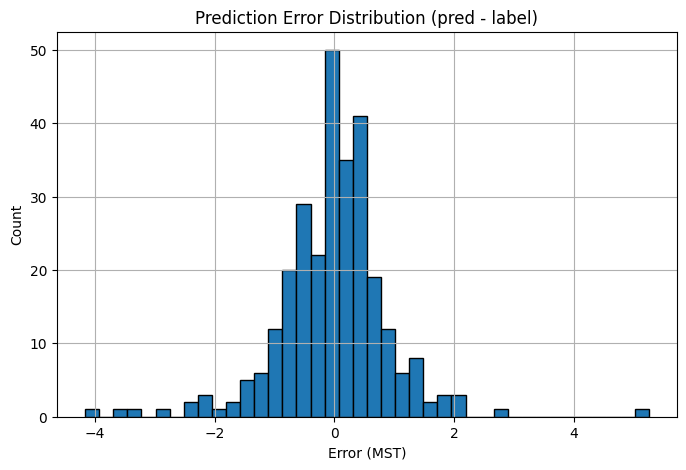

In [ ]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg16, vit_b_16, ViT_B_16_Weights
from torch.amp import autocast


# ============================================================
# 0. REPRODUCIBILITY & DEVICE
# ============================================================

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ============================================================
# 1. PREPROCESSORS
# ============================================================

class PaperPreprocessorLAB:
    """
    Preprocessing aligned with the paper for VGG-16:
    - Input: BGR image (cv2)
    - BGR -> RGB
    - Optional H/V flips (augmentation)
    - Resize to 224x224
    - RGB -> LAB via OpenCV
    - Return LAB tensor [3, H, W] in OpenCV range (no /255)
    """
    def __init__(self, augment: bool = False):
        self.augment = augment
        self.target_size = (224, 224)

    def __call__(self, img_bgr: np.ndarray) -> torch.Tensor:
        # BGR -> RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Augmentation
        if self.augment:
            if np.random.rand() < 0.5:
                img_rgb = cv2.flip(img_rgb, 1)  # horizontal
            if np.random.rand() < 0.5:
                img_rgb = cv2.flip(img_rgb, 0)  # vertical

        # Resize
        img_rgb = cv2.resize(img_rgb, self.target_size, interpolation=cv2.INTER_AREA)

        # RGB -> LAB
        img_lab = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2LAB).astype(np.float32)  # [H,W,3]

        # To tensor [C,H,W]
        img_lab = torch.from_numpy(img_lab).permute(2, 0, 1)
        return img_lab


class RGBPreprocessorViT:
    """
    Preprocessing for ViT regression model:
    - Input: BGR
    - BGR -> RGB
    - Optional flips
    - Resize 224x224
    - To float [0,1]
    - Normalise with ImageNet mean/std (ViT pretraining stats)
    """
    def __init__(self, augment: bool = False):
        self.augment = augment
        self.target_size = (224, 224)
        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        self.std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    def __call__(self, img_bgr: np.ndarray) -> torch.Tensor:
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.augment:
            if np.random.rand() < 0.5:
                img_rgb = cv2.flip(img_rgb, 1)
            if np.random.rand() < 0.5:
                img_rgb = cv2.flip(img_rgb, 0)

        img_rgb = cv2.resize(img_rgb, self.target_size, interpolation=cv2.INTER_AREA)
        img = torch.from_numpy(img_rgb.astype(np.float32) / 255.0).permute(2,0,1)  # [C,H,W]

        # Normalise
        img = (img - self.mean) / self.std
        return img


# ============================================================
# 2. MODELS
# ============================================================

class PaperVGG16Regression(nn.Module):
    """
    VGG-16 regression model as per paper:
    - No pretrained weights
    - LAB input [3,224,224]
    - 25088 -> 4096 -> 1024 -> 1
    """
    def __init__(self):
        super().__init__()
        base = vgg16(weights=None)  # from scratch
        self.features = base.features

        self.reg_head = nn.Sequential(
            nn.Linear(25088, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.reg_head(x)
        return x  # [B,1]


class ViTRegression(nn.Module):
    """
    ViT-B/16 regression head:
    - Uses pretrained ImageNet weights
    - RGB input with ImageNet normalisation
    - Head: 768 -> 1
    """
    def __init__(self, pretrained: bool = True):
        super().__init__()
        if pretrained:
            # weights = ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
            weights = ViT_B_16_Weights.IMAGENET1K_V1
            base = vit_b_16(weights=weights)
        else:
            base = vit_b_16(weights=None)

        # Replace classification head with regression head
        in_dim = base.heads.head.in_features
        base.heads.head = nn.Linear(in_dim, 1)

        self.model = base

    def forward(self, x):
        return self.model(x)  # [B,1]


def build_model(model_type: str):
    model_type = model_type.lower()
    if model_type == "vgg_paper":
        return PaperVGG16Regression()
    elif model_type == "vit_reg":
        return ViTRegression(pretrained=True)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")


def build_preprocessors(model_type: str):
    model_type = model_type.lower()
    if model_type == "vgg_paper":
        train_tf = PaperPreprocessorLAB(augment=True)
        val_tf   = PaperPreprocessorLAB(augment=False)
    elif model_type == "vit_reg":
        train_tf = RGBPreprocessorViT(augment=True)
        val_tf   = RGBPreprocessorViT(augment=False)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    return train_tf, val_tf


# ============================================================
# 3. MST PALETTE & CIEDE2000 LOSS
# ============================================================

# Hard-coded MST palette (hex) from Google's MST scale.
MST_PALETTE_HEX = [
    "#f6ede4", "#f3e7db", "#f7ead0", "#eadaba", "#d7bd96",
    "#a07e56", "#825c43", "#604134", "#3a312a", "#292420"
]


def hex_to_rgb(hex_str: str):
    hex_str = hex_str.lstrip("#")
    r = int(hex_str[0:2], 16)
    g = int(hex_str[2:4], 16)
    b = int(hex_str[4:6], 16)
    return r, g, b


def rgb_to_lab_np(r, g, b):
    """
    Minimal sRGB->CIELAB conversion in numpy.
    Inputs: 0-255 ints
    Returns: L,a,b in standard Lab (approximate is fine for loss)
    """
    # sRGB -> [0,1]
    rgb = np.array([r, g, b], dtype=np.float64) / 255.0

    def srgb_to_linear(c):
        return np.where(c <= 0.04045, c / 12.92, ((c + 0.055) / 1.055) ** 2.4)

    rgb_lin = srgb_to_linear(rgb)

    # sRGB D65 conversion
    M = np.array([[0.4124564, 0.3575761, 0.1804375],
                  [0.2126729, 0.7151522, 0.0721750],
                  [0.0193339, 0.1191920, 0.9503041]])
    xyz = M @ rgb_lin

    # Reference white D65
    Xn, Yn, Zn = 0.95047, 1.00000, 1.08883
    x, y, z = xyz[0] / Xn, xyz[1] / Yn, xyz[2] / Zn

    def f(t):
        delta = 6/29
        return np.where(t > delta**3, np.cbrt(t), (t / (3*delta**2) + 4/29))

    fx, fy, fz = f(x), f(y), f(z)

    L = 116 * fy - 16
    a = 500 * (fx - fy)
    b = 200 * (fy - fz)
    return L, a, b


def build_mst_lab_palette():
    labs = []
    for h in MST_PALETTE_HEX:
        r, g, b = hex_to_rgb(h)
        L, a, b_ = rgb_to_lab_np(r, g, b)
        labs.append([L, a, b_])
    return np.array(labs, dtype=np.float32)  # [10,3]


class CIEDE2000Loss(nn.Module):
    """
    Differentiable CIEDE2000 loss over MST indices:
    - Map predicted MST index -> LAB via continuous interpolation over MST palette
    - Map ground-truth MST label -> LAB at exact bin
    - Compute ΔE00 between LAB(pred) and LAB(gt)
    - Average over batch
    """

    def __init__(self):
        super().__init__()
        mst_lab = build_mst_lab_palette()  # [10,3]
        # Store as buffer so it moves with model to device
        self.register_buffer("mst_lab", torch.from_numpy(mst_lab))  # [10,3]

    def mst_to_lab(self, mst_values: torch.Tensor) -> torch.Tensor:
        """
        mst_values: [B] float in approx [1,10]
        Returns LAB: [B,3]
        """
        x = mst_values - 1.0  # 0..9
        x = x.clamp(0.0, 9.0)

        lower_idx = torch.floor(x).long().to(mst_values.device)
        upper_idx = torch.clamp(lower_idx + 1, max=9).to(mst_values.device)
        frac = (x - lower_idx.float()).unsqueeze(-1)  # [B,1]

        # lab_lower = self.mst_lab[lower_idx]  # [B,3]
        # lab_upper = self.mst_lab[upper_idx]  # [B,3]
        lab_palette = self.mst_lab.to(mst_values.device)
        lab_lower = lab_palette[lower_idx]
        lab_upper = lab_palette[upper_idx]
        lab = lab_lower + frac * (lab_upper - lab_lower)
        return lab  # [B,3]

    @staticmethod
    def ciede2000(lab1: torch.Tensor, lab2: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
        """
        lab1, lab2: [B,3] in L*a*b*.
        Returns ΔE00: [B]
        Implementation adapted to torch.
        """
        L1, a1, b1 = lab1[:,0], lab1[:,1], lab1[:,2]
        L2, a2, b2 = lab2[:,0], lab2[:,1], lab2[:,2]

        # Mean L*
        L_bar = 0.5 * (L1 + L2)

        C1 = torch.sqrt(a1**2 + b1**2 + eps)
        C2 = torch.sqrt(a2**2 + b2**2 + eps)
        C_bar = 0.5 * (C1 + C2)

        C_bar7 = C_bar**7
        G = 0.5 * (1 - torch.sqrt(C_bar7 / (C_bar7 + 25**7 + eps)))

        a1_prime = (1 + G) * a1
        a2_prime = (1 + G) * a2

        C1_prime = torch.sqrt(a1_prime**2 + b1**2 + eps)
        C2_prime = torch.sqrt(a2_prime**2 + b2**2 + eps)
        C_bar_prime = 0.5 * (C1_prime + C2_prime)

        # Hue angle in degrees
        def atan2_deg(y, x):
            return torch.rad2deg(torch.atan2(y, x)) % 360

        h1_prime = atan2_deg(b1, a1_prime)
        h2_prime = atan2_deg(b2, a2_prime)

        # ΔL'
        delta_L_prime = L2 - L1
        # ΔC'
        delta_C_prime = C2_prime - C1_prime

        # Δh'
        h_diff = h2_prime - h1_prime
        delta_h_prime = torch.where(
            C1_prime * C2_prime == 0,
            torch.zeros_like(h_diff),
            torch.where(
                h_diff.abs() <= 180,
                h_diff,
                h_diff - 360 * torch.sign(h_diff)
            )
        )

        delta_H_prime = 2 * torch.sqrt(C1_prime * C2_prime + eps) * torch.sin(torch.deg2rad(delta_h_prime / 2))

        # Mean L', C', h'
        L_bar_prime = 0.5 * (L1 + L2)
        C_bar_prime = 0.5 * (C1_prime + C2_prime)

        h_bar_prime = torch.where(
            C1_prime * C2_prime == 0,
            h1_prime + h2_prime,
            torch.where(
                (h1_prime - h2_prime).abs() <= 180,
                0.5 * (h1_prime + h2_prime),
                torch.where(
                    h1_prime + h2_prime < 360,
                    0.5 * (h1_prime + h2_prime + 360),
                    0.5 * (h1_prime + h2_prime - 360),
                )
            )
        )

        T = (
            1
            - 0.17 * torch.cos(torch.deg2rad(h_bar_prime - 30))
            + 0.24 * torch.cos(torch.deg2rad(2 * h_bar_prime))
            + 0.32 * torch.cos(torch.deg2rad(3 * h_bar_prime + 6))
            - 0.20 * torch.cos(torch.deg2rad(4 * h_bar_prime - 63))
        )

        delta_theta = 30 * torch.exp(-((h_bar_prime - 275) / 25) ** 2)
        R_C = 2 * torch.sqrt(C_bar_prime**7 / (C_bar_prime**7 + 25**7 + eps))
        S_L = 1 + (0.015 * (L_bar_prime - 50) ** 2) / torch.sqrt(20 + (L_bar_prime - 50) ** 2 + eps)
        S_C = 1 + 0.045 * C_bar_prime
        S_H = 1 + 0.015 * C_bar_prime * T
        R_T = -torch.sin(torch.deg2rad(2 * delta_theta)) * R_C

        dE = torch.sqrt(
            (delta_L_prime / (S_L + eps))**2 +
            (delta_C_prime / (S_C + eps))**2 +
            (delta_H_prime / (S_H + eps))**2 +
            R_T * (delta_C_prime / (S_C + eps)) * (delta_H_prime / (S_H + eps))
        )
        return dE

    def forward(self, preds: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        preds, targets: [B] MST indices (float)
        """
        lab_pred = self.mst_to_lab(preds)
        lab_true = self.mst_to_lab(targets)
        delta_e = self.ciede2000(lab_pred, lab_true)
        return delta_e.mean()


def build_loss(loss_type: str):
    loss_type = loss_type.lower()
    if loss_type == "mse":
        return nn.MSELoss()
    elif loss_type == "ciede2000":
        return CIEDE2000Loss()
    else:
        raise ValueError(f"Unknown loss_type: {loss_type}")


# ============================================================
# 4. DATASET & DATALOADERS
# ============================================================

class SkinToneDataset(Dataset):
    """
    Expects DataFrame with:
      - segmented_path
      - mst_label
    """
    def __init__(self, df: pd.DataFrame, transform):
        self.paths = df["segmented_path"].tolist()
        self.labels = df["mst_label"].astype(float).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        label = self.labels[idx]

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Failed to read image: {img_path}")

        img = self.transform(img)
        label = torch.tensor(label, dtype=torch.float32)
        return img, label


def build_dataloaders(csv_path: str,
                      model_type: str,
                      batch_size: int = 32,
                      val_ratio: float = 0.2):
    df = pd.read_csv(csv_path)
    df = df.dropna(subset=["segmented_path", "mst_label"])

    indices = np.arange(len(df))
    np.random.shuffle(indices)
    split = int(len(indices) * (1 - val_ratio))
    train_idx = indices[:split]
    val_idx   = indices[split:]

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    print(f"Total samples: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")

    train_tf, val_tf = build_preprocessors(model_type)

    train_ds = SkinToneDataset(train_df, transform=train_tf)
    val_ds   = SkinToneDataset(val_df, transform=val_tf)

    # On Windows, num_workers=0 avoids deadlocks with OpenCV
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader


# ============================================================
# 5. METRICS
# ============================================================

def accuracy_at_threshold(preds: torch.Tensor,
                          labels: torch.Tensor,
                          dist: float = 0.5) -> float:
    diffs = torch.abs(preds - labels)
    return (diffs <= dist).float().mean().item()


def mae(preds: torch.Tensor, labels: torch.Tensor) -> float:
    return torch.mean(torch.abs(preds - labels)).item()


def rmse(preds: torch.Tensor, labels: torch.Tensor) -> float:
    return torch.sqrt(torch.mean((preds - labels) ** 2)).item()


def soft_accuracy(preds: torch.Tensor, labels: torch.Tensor, max_range: float = 9.0) -> float:
    """
    Soft accuracy: 1 - |pred-label| / max_range, clipped to [0,1].
    Gives a continuous 'accuracy-like' score.
    """
    diff = torch.abs(preds - labels)
    soft = 1.0 - diff / max_range
    soft = torch.clamp(soft, 0.0, 1.0)
    return soft.mean().item()


# ============================================================
# 6. TRAINING LOOP (WITH SCHEDULER, EARLY STOPPING, AMP)
# ============================================================

from tqdm import tqdm

def train_model(
    csv_path: str,
    model_type: str = "vgg_paper",    # or "vit_reg"
    loss_type: str  = "mse",          # or "ciede2000"
    num_epochs: int = 40,
    batch_size: int = 32,
    lr: float = 1e-5,
    momentum: float = 0.9,
    patience: int = 8,
    checkpoint_path: str = "best_model.pth",
    use_amp: bool = True
):
    # ------------------------------
    # Data
    # ------------------------------
    train_loader, val_loader = build_dataloaders(csv_path, model_type, batch_size=batch_size)

    # ------------------------------
    # Model, loss, optimizer, scheduler
    # ------------------------------
    model = build_model(model_type).to(device)
    criterion = build_loss(loss_type)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, verbose=True
    )

    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_val_loss = float("inf")
    epochs_without_improve = 0

    print(f"Training {model_type} on {device} with {loss_type} loss, early stopping (patience={patience})")

    for epoch in range(num_epochs):
        # ----------------------------------------------------------
        # TRAIN
        # ----------------------------------------------------------
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", ncols=120)
        for imgs, labels in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            with autocast(device_type="cuda", dtype=torch.float16, enabled=use_amp):
                preds = model(imgs).squeeze(1)   # [B]
                loss = criterion(preds, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # ----------------------------------------------------------
        # VALIDATE
        # ----------------------------------------------------------
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                preds = model(imgs).squeeze(1)
                loss = criterion(preds, labels)
                val_loss += loss.item()

                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)

        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        acc05 = accuracy_at_threshold(all_preds, all_labels, dist=0.5)
        acc10 = accuracy_at_threshold(all_preds, all_labels, dist=1.0)
        acc20 = accuracy_at_threshold(all_preds, all_labels, dist=2.0)
        mae_v = mae(all_preds, all_labels)
        rmse_v = rmse(all_preds, all_labels)
        soft_acc_v = soft_accuracy(all_preds, all_labels, max_range=9.0)

        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] | "
            f"TrainLoss={avg_train_loss:.4f} | ValLoss={avg_val_loss:.4f}\n"
            f"MAE={mae_v:.3f} | RMSE={rmse_v:.3f} | SoftAcc={soft_acc_v*100:.2f}%\n"
            f"Acc@0.5={acc05*100:.2f}% | Acc@1.0={acc10*100:.2f}% | Acc@2.0={acc20*100:.2f}%\n"
        )

        # ----------------------------------------------------------
        # EARLY STOP + CHECKPOINT
        # ----------------------------------------------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✓ Saved new best model to {checkpoint_path} (ValLoss={best_val_loss:.4f})")
        else:
            epochs_without_improve += 1
            print(f"✗ No improvement for {epochs_without_improve} epoch(s).")

        if epochs_without_improve >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs without improvement.")
            break

    print(f"\nTraining complete. Best ValLoss={best_val_loss:.4f}")
    print(f"Best model weights saved to: {checkpoint_path}")
    return model


# ============================================================
# 7. ERROR VISUALISATION UTILITIES
# ============================================================

def plot_error_distribution(preds: torch.Tensor,
                            labels: torch.Tensor,
                            save_path: str = None):
    """
    Plot histograms of prediction error (pred - label).
    """
    preds_np = preds.numpy()
    labels_np = labels.numpy()
    errors = preds_np - labels_np

    plt.figure(figsize=(8,5))
    plt.hist(errors, bins=40, edgecolor="black")
    plt.title("Prediction Error Distribution (pred - label)")
    plt.xlabel("Error (MST)")
    plt.ylabel("Count")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    else:
        plt.show()


# ============================================================
# 8. ENTRY POINT EXAMPLE
# ============================================================

if __name__ == "__main__":
    # Update this to your MST-E or FACET CSV
    CSV_PATH = r'G:\\Thesis\\FACET_Dataset\\Segmented_FACET\\facet_final.csv'

    # Choose model & loss:
    #   model_type: "vgg_paper" (LAB, VGG16) or "vit_reg" (RGB, ViT)
    #   loss_type : "mse" or "ciede2000"
    MODEL_TYPE = "vit_reg" #"vgg_paper"
    LOSS_TYPE  = "mse"           # try "ciede2000" after baseline

    model = train_model(
        csv_path=CSV_PATH,
        model_type=MODEL_TYPE,
        loss_type=LOSS_TYPE,
        num_epochs=40,
        batch_size=32,
        lr=1e-4, #1e-5,
        momentum=0.9,
        patience=8,
        checkpoint_path=f"best_{MODEL_TYPE}_{LOSS_TYPE}.pth",
        use_amp=True
    )

    # Example: load val set once more to visualise final errors
    train_loader, val_loader = build_dataloaders(CSV_PATH, MODEL_TYPE, batch_size=32)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            preds = model(imgs).squeeze(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    plot_error_distribution(all_preds, all_labels, save_path=None)


In [22]:
from tqdm import tqdm

def train_model(
    csv_path: str,
    model_type: str = "vgg_paper",    # or "vit_reg"
    loss_type: str  = "mse",          # or "ciede2000"
    num_epochs: int = 40,
    batch_size: int = 32,
    lr: float = 1e-4,
    momentum: float = 0.9,
    patience: int = 8,
    checkpoint_path: str = "best_model.pth",
    use_amp: bool = True
):
    # ------------------------------
    # Data
    # ------------------------------
    train_loader, val_loader = build_dataloaders(csv_path, model_type, batch_size=batch_size)

    # ------------------------------
    # Model & loss
    # ------------------------------
    model = build_model(model_type).to(device)
    criterion = build_loss(loss_type)

    # ------------------------------
    # Optimizer (different for VGG vs ViT)
    # ------------------------------
    model_type_l = model_type.lower()
    loss_type_l = loss_type.lower()

    if model_type_l == "vit_reg":
        # ViT wants AdamW
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=0.05
        )
        # Cosine schedule over epochs
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=num_epochs
        )
    else:
        # VGG-style setup: SGD + ReduceLROnPlateau
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=momentum
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.5, patience=3
        )

    # ------------------------------
    # AMP – only for MSE (not for CIEDE2000)
    # ------------------------------
    amp_enabled = use_amp and (loss_type_l == "mse")
    scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    best_val_loss = float("inf")
    epochs_without_improve = 0

    print(
        f"Training {model_type} on {device} with {loss_type} loss, "
        f"early stopping (patience={patience}), AMP={'ON' if amp_enabled else 'OFF'}"
    )

    for epoch in range(num_epochs):
        # ----------------------------------------------------------
        # TRAIN
        # ----------------------------------------------------------
        model.train()
        running_loss = 0.0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", ncols=120)
        for imgs, labels in pbar:
            imgs = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad()

            # Use AMP only when enabled (MSE case)
            with autocast(device_type="cuda", dtype=torch.float16, enabled=amp_enabled):
                preds = model(imgs).squeeze(1)   # [B]
                loss = criterion(preds, labels)

            if amp_enabled:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            running_loss += loss.item()
            pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

        avg_train_loss = running_loss / len(train_loader)

        # ----------------------------------------------------------
        # VALIDATE
        # ----------------------------------------------------------
        model.eval()
        val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs = imgs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)

                preds = model(imgs).squeeze(1)
                loss = criterion(preds, labels)
                val_loss += loss.item()

                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())

        avg_val_loss = val_loss / len(val_loader)
        all_preds = torch.cat(all_preds)
        all_labels = torch.cat(all_labels)

        # Step scheduler
        if model_type_l == "vit_reg":
            # Cosine scheduler – step once per epoch
            scheduler.step()
        else:
            # Plateau scheduler – step on val loss
            scheduler.step(avg_val_loss)

        # ----------------------------------------------------------
        # METRICS
        # ----------------------------------------------------------
        acc05 = accuracy_at_threshold(all_preds, all_labels, dist=0.5)
        acc10 = accuracy_at_threshold(all_preds, all_labels, dist=1.0)
        acc20 = accuracy_at_threshold(all_preds, all_labels, dist=2.0)
        mae_v = mae(all_preds, all_labels)
        rmse_v = rmse(all_preds, all_labels)
        soft_acc_v = soft_accuracy(all_preds, all_labels, max_range=9.0)

        print(
            f"\nEpoch [{epoch+1}/{num_epochs}] | "
            f"TrainLoss={avg_train_loss:.4f} | ValLoss={avg_val_loss:.4f}\n"
            f"MAE={mae_v:.3f} | RMSE={rmse_v:.3f} | SoftAcc={soft_acc_v*100:.2f}%\n"
            f"Acc@0.5={acc05*100:.2f}% | Acc@1.0={acc10*100:.2f}% | Acc@2.0={acc20*100:.2f}%\n"
        )

        # ----------------------------------------------------------
        # EARLY STOP + CHECKPOINT
        # ----------------------------------------------------------
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_without_improve = 0
            torch.save(model.state_dict(), checkpoint_path)
            print(f"✓ Saved new best model to {checkpoint_path} (ValLoss={best_val_loss:.4f})")
        else:
            epochs_without_improve += 1
            print(f"✗ No improvement for {epochs_without_improve} epoch(s).")

        if epochs_without_improve >= patience:
            print(f"\nEarly stopping triggered after {patience} epochs without improvement.")
            break

    print(f"\nTraining complete. Best ValLoss={best_val_loss:.4f}")
    print(f"Best model weights saved to: {checkpoint_path}")
    return model


if __name__ == "__main__":
    # Update this to your MST-E or FACET CSV
    CSV_PATH = r'G:\\Thesis\\FACET_Dataset\\Segmented_FACET\\facet_final.csv'

    # Choose model & loss:
    #   model_type: "vgg_paper" (LAB, VGG16) or "vit_reg" (RGB, ViT)
    #   loss_type : "mse" or "ciede2000"
    MODEL_TYPE = "vit_reg" 
    LOSS_TYPE  = "ciede2000"

    model = train_model(
        csv_path=CSV_PATH,
        model_type=MODEL_TYPE,
        loss_type=LOSS_TYPE,
        num_epochs=40,
        batch_size=32,
        lr=1e-4, #1e-5,
        momentum=0.9,
        patience=8,
        checkpoint_path=f"best_{MODEL_TYPE}_{LOSS_TYPE}.pth",
        use_amp=True
    )

    # Example: load val set once more to visualise final errors
    train_loader, val_loader = build_dataloaders(CSV_PATH, MODEL_TYPE, batch_size=32)
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(device)
            preds = model(imgs).squeeze(1).cpu()
            all_preds.append(preds)
            all_labels.append(labels)
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    plot_error_distribution(all_preds, all_labels, save_path=None)


Total samples: 1435 | Train: 1148 | Val: 287
Training vit_reg on cuda with ciede2000 loss, early stopping (patience=8), AMP=OFF


Epoch 1/40: 100%|███████████████████████████████████████████████████| 36/36 [07:20<00:00, 12.24s/it, batch_loss=12.7132]



Epoch [1/40] | TrainLoss=11.3913 | ValLoss=9.5003
MAE=1.084 | RMSE=1.389 | SoftAcc=87.95%
Acc@0.5=31.01% | Acc@1.0=57.84% | Acc@2.0=83.62%

✓ Saved new best model to best_vit_reg_ciede2000.pth (ValLoss=9.5003)


Epoch 2/40: 100%|███████████████████████████████████████████████████| 36/36 [07:08<00:00, 11.91s/it, batch_loss=11.1557]



Epoch [2/40] | TrainLoss=9.3545 | ValLoss=8.0826
MAE=0.956 | RMSE=1.198 | SoftAcc=89.38%
Acc@0.5=29.27% | Acc@1.0=59.58% | Acc@2.0=91.99%

✓ Saved new best model to best_vit_reg_ciede2000.pth (ValLoss=8.0826)


...


Epoch [11/40] | TrainLoss=5.1031 | ValLoss=8.2711
MAE=0.963 | RMSE=1.318 | SoftAcc=89.30%
Acc@0.5=37.98% | Acc@1.0=62.02% | Acc@2.0=89.90%

✗ No improvement for 6 epoch(s).


Epoch 12/40: 100%|███████████████████████████████████████████████████| 36/36 [07:06<00:00, 11.84s/it, batch_loss=5.6690]



Epoch [12/40] | TrainLoss=5.1655 | ValLoss=8.5361
MAE=0.991 | RMSE=1.301 | SoftAcc=88.99%
Acc@0.5=32.40% | Acc@1.0=58.89% | Acc@2.0=91.29%

✗ No improvement for 7 epoch(s).


Epoch 13/40:  97%|█████████████████████████████████████████████████▌ | 35/36 [06:44<00:11, 11.55s/it, batch_loss=4.7104]


KeyboardInterrupt: 